In [1]:
# steps:
    # create a new BoostFractor for editing
    # run simulations before editing BoostFractor
    # edit BoostFractor with your changes
    # run simulations with new BoostFractor but with no Bfield specified
    # run simulations with Bfield specified

In [2]:
using Pkg
Pkg.develop(path="/matnoire/dixon/MADMAX/Booster_sims/Bfield-variation/BoostFractor.jl")

   Resolving package versions...
  No Changes to `/misc/matnoire/dixon/Project.toml`
  No Changes to `/misc/matnoire/dixon/Manifest.toml`


In [3]:
using BoostFractor
include("/matnoire/dixon/MADMAX/Booster_sims/Bfield-variation/BoostFractor.jl/examples/transformer_optim_utilities.jl")
using Plots
using LaTeXStrings
using DataFrames
using CSV

In [4]:
function interpolate_B_plane(df, z, Xgrid, Ygrid; p=2.0, eps=1e-12)
    # Extract one z-plane and remove duplicate (X,Y) points
    plane = unique(df[df.Z .== z, :], [:X, :Y])
    x = plane.X
    y = plane.Y
    b = plane.B
    Nx = length(Xgrid)
    Ny = length(Ygrid)
    B = zeros(Nx, Ny, 1)
    for (i, Xi) in enumerate(Xgrid), (j, Yi) in enumerate(Ygrid)
        num = 0.0
        den = 0.0
        found = false
        for k in eachindex(b)
            dx = Xi - x[k]
            dy = Yi - y[k]
            d2 = dx*dx + dy*dy
            # Exactly on a data point
            if d2 < eps
                B[i,j,1] = b[k]
                found = true
                break
            end
            w = 1 / d2^(p/2)
            num += w*b[k]
            den += w
        end
        if !found
            B[i,j,1] = num/den
        end
    end
    return B
end

interpolate_B_plane (generic function with 1 method)

In [5]:
df = CSV.read("MadMax_4T_Diple_Field Mapping_R300mm_Size15mm_Angle_360Degree_Size 22_5Degree_Z500 mm_Size50mm_Tesla_20260624.table",
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false,
    skipto=10
)

rename!(df, [:X, :Y, :Z, :Bx, :By, :Bz, :B]);

In [6]:
X_data = sort(unique(df.X))
Y_data = sort(unique(df.Y))
Z_data = sort(unique(df.Z))

println(maximum(X_data))
println(maximum(Y_data))

xidx = Dict(x => i for (i,x) in enumerate(X_data))
yidx = Dict(y => j for (j,y) in enumerate(Y_data))
zidx = Dict(z => k for (k,z) in enumerate(Z_data))

# One (Nx, Ny, 1) array per z-plane
Bplanes = [zeros(length(X_data), length(Y_data), 1) for _ in Z_data]

for row in eachrow(df)
    Bplanes[zidx[row.Z]][xidx[row.X], yidx[row.Y], 1] = row.B
end

300.0
300.0


163


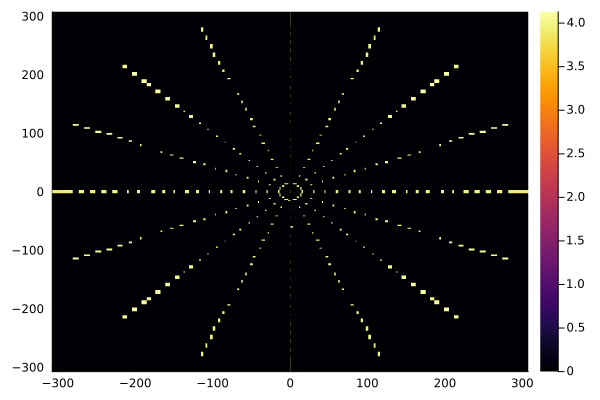

In [7]:
B_plot = Bplanes[5][:,:,1]
println(length(X_data))
plot()
heatmap!(X_data, Y_data, B_plot')

In [8]:
dx = 0.0025
X_mesh = -0.3:dx:0.3
Y_mesh = -0.3:dx:0.3

B_perZ = Vector{Array{Float64,3}}(undef, length(Z_data))
println(size(B_perZ))
for (k, z) in enumerate(Z_data)
    B_perZ[k] = interpolate_B_plane(df, z, X_mesh.*1e3, Y_mesh.*1e3)
end
println(maximum(B_perZ[5]))

(11,)
4.127469181854312


163


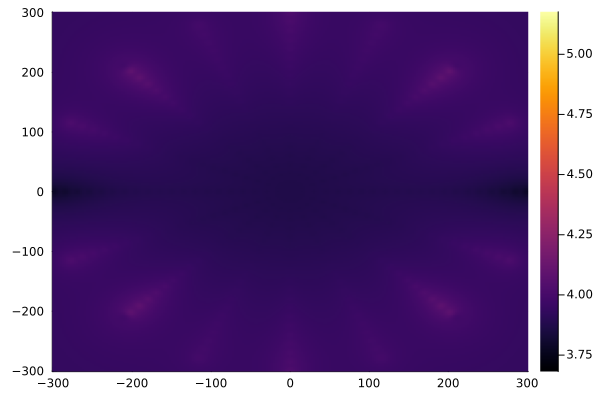

In [24]:
B_plot = B_perZ[2][:,:,1]
println(length(X_data))
colorrange = (minimum(df.B), maximum(df.B))
plot()
heatmap!(X_mesh*1e3, Y_mesh*1e3, B_plot', clim=colorrange)
savefig("Bfield_interploate.png")
plot!()

In [11]:
coords = SeedCoordinateSystem(X = X_mesh , Y = Y_mesh)
    
diskR = 0.15

# Jacob's minimal dielectric setup
Ndisks = 20
n_region = 2*Ndisks+2

distance = [0.0, 9.872, 1.0, 10.301, 1.0, 9.547, 1.0, 11.24, 1.0, 9.872, 1.0, 9.798, 1.0, 10.564, 1.0, 11.187, 1.0, 9.5, 1.0, 10.408, 1.0, 10.183, 1.0, 10.377, 1.0, 10.919, 1.0, 11.005, 1.0, 11.387, 1.0, 11.414, 1.0, 10.535, 1.0, 10.106, 1.0, 9.597, 1.0, 9.878, 1.0, 0.0]*1e-3

epsilon = 9.3
eps = Array{Complex{Float64}}([i==1 ? NaN : i%2==0 ? 1 : epsilon for i=1:n_region])   

# Initialize modes

Mmax = 3
Lmax = 3
modes = SeedModes(coords, ThreeDim=true, Mmax=Mmax, Lmax=Lmax, diskR=diskR)

# generate Gaussian field E_gauss(x,y)
fc = 18.5e9
beam_waist = 0.085 # 0.075 # <- check this number
field_gauss = gauss_profile(coords;z = 1e-9, omega0 = beam_waist, f = fc) 
# find the coefficients of the transverse modes (R_1, R_2,...,R_m), where E_gauss = sum_m[R_m*u_m(x,y)]
m_reflect = field2modes(field_gauss, coords, modes;diskR=diskR); 

sbdry = SeedSetupBoundaries(coords, diskno=Ndisks, distance=distance, epsilon=eps);

In [12]:
prop = propagator;

d_freq = 0.01*1e9
frequencies = 18e9:d_freq:19e9

#Calculate FULL frequency prop matrix of initial setup for plotting
prop_matrix_grid_plot = calc_propagation_matrices_grid(sbdry,coords,modes,0,frequencies;prop=prop, diskR=diskR)
prop_matrix_plot = [prop_matrix_grid_plot[r,f,1,1,1,:,:] for r=1:n_region, f=1:length(frequencies)];

In [13]:
Eout_init = calc_modes(sbdry,coords,modes,frequencies, prop_matrix_plot, m_reflect;prop=prop, diskR=diskR);
coupled_power1 = abs2.(sum(conj.(Eout_init[1,:,:]).*m_reflect, dims=1)[1,:]);

In [14]:
Z_sim = Z_data.*1e-3

cumdists = cumsum(distance) .- 0.05
# find closest z slice to each region boundary
closest_idx = [argmin(abs.(Z_sim .- z)) for z in cumdists]
closest_z   = Z_sim[closest_idx]
println(closest_idx)


[5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10]


In [15]:
Eout_init = calc_modes(sbdry,coords,modes,frequencies, prop_matrix_plot, m_reflect;prop=prop, diskR=diskR, Bfield=B_perZ,Bfield_idx=closest_idx);
coupled_powerB = abs2.(sum(conj.(Eout_init[1,:,:]).*m_reflect, dims=1)[1,:]);

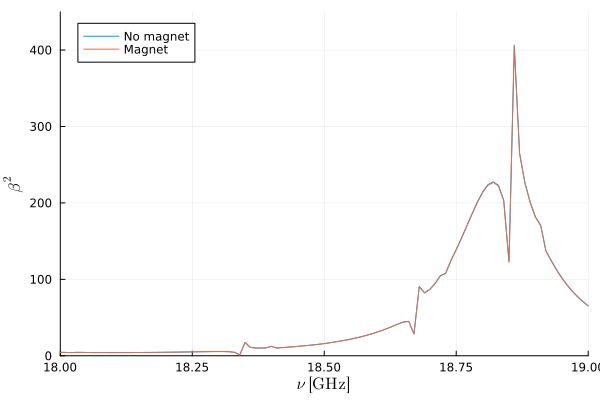

In [23]:
plot(xlim=(18, 19), ylim=(0,450))
plot!(xlabel=L"ν \  \mathrm{[GHz]}",ylabel=L"\beta^2")
plot!(frequencies.*1e-9, coupled_power1, label="No magnet")
plot!(frequencies.*1e-9, coupled_powerB, label="Magnet")
plot!()